In [1]:
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

In [2]:
df = pd.read_csv("data/ZTF_DESI_matched_lc_cuts_z_cuts_hostprop_cleaned_tripp_uncorrected_chi2_only.csv")
y = df["residuals"]

all_features = [
    "ZTF_x1",
    "ZTF_c",
    "DESI_FASTSPEC_LOGMSTAR",
    "DESI_FASTSPEC_SFR",
    "DESI_FASTSPEC_VDISP",
    "DESI_FASTSPEC_DN4000",
    "DESI_FASTSPEC_g_minus_r",
    "DESI_FASTSPEC_AGE",
    "DESI_METADATA_Z"
]

short_names = {
    "ZTF_x1": "x₁",
    "ZTF_c": "c",
    "DESI_FASTSPEC_LOGMSTAR": "logM★",
    "DESI_FASTSPEC_SFR": "SFR",
    "DESI_FASTSPEC_VDISP": "σ_v",
    "DESI_FASTSPEC_DN4000": "Dn4000",
    "DESI_FASTSPEC_g_minus_r": "g−r",
    "DESI_FASTSPEC_AGE": "Age",
    "DESI_METADATA_Z": "z"
}

best_params = {'n_estimators': 600, 'max_depth': 26, 'min_samples_split': 7, 'min_samples_leaf': 3, 'max_features': None, 'bootstrap': True, 'max_samples': 0.5041681530892771}


X = df[all_features]
rf = RandomForestRegressor(**best_params)
rf.fit(X, y)

importances = pd.Series(
    rf.feature_importances_,
    index=[short_names[f] for f in all_features]
).sort_values(ascending=False)

print("Feature Importances (MDI):")
print(importances)

Feature Importances (MDI):
c         0.664048
x₁        0.191142
z         0.043698
Dn4000    0.021772
g−r       0.020291
Age       0.016681
SFR       0.015255
logM★     0.014370
σ_v       0.012744
dtype: float64


Baseline RMS (no ML): 0.3851
Baseline mean Δμ (no ML): -0.1658
                                           features  n_features      rms  mean_delta_mu
x₁ + c + logM★ + SFR + σ_v + Dn4000 + g−r + Age + z           9 0.133338       0.000482
            x₁ + c + logM★ + SFR + Dn4000 + g−r + z           7 0.133345       0.001071
      x₁ + c + logM★ + σ_v + Dn4000 + g−r + Age + z           8 0.133359       0.000290
        x₁ + c + SFR + σ_v + Dn4000 + g−r + Age + z           8 0.133490       0.001467
      x₁ + c + logM★ + SFR + σ_v + Dn4000 + Age + z           8 0.133503       0.000923
      x₁ + c + logM★ + SFR + Dn4000 + g−r + Age + z           8 0.133518       0.002011
            x₁ + c + logM★ + Dn4000 + g−r + Age + z           7 0.133528       0.000739
              x₁ + c + SFR + Dn4000 + g−r + Age + z           7 0.133657       0.000299
      x₁ + c + logM★ + SFR + σ_v + Dn4000 + g−r + z           8 0.133715       0.001278
         x₁ + c + logM★ + SFR + σ_v + g−r + Age + z      

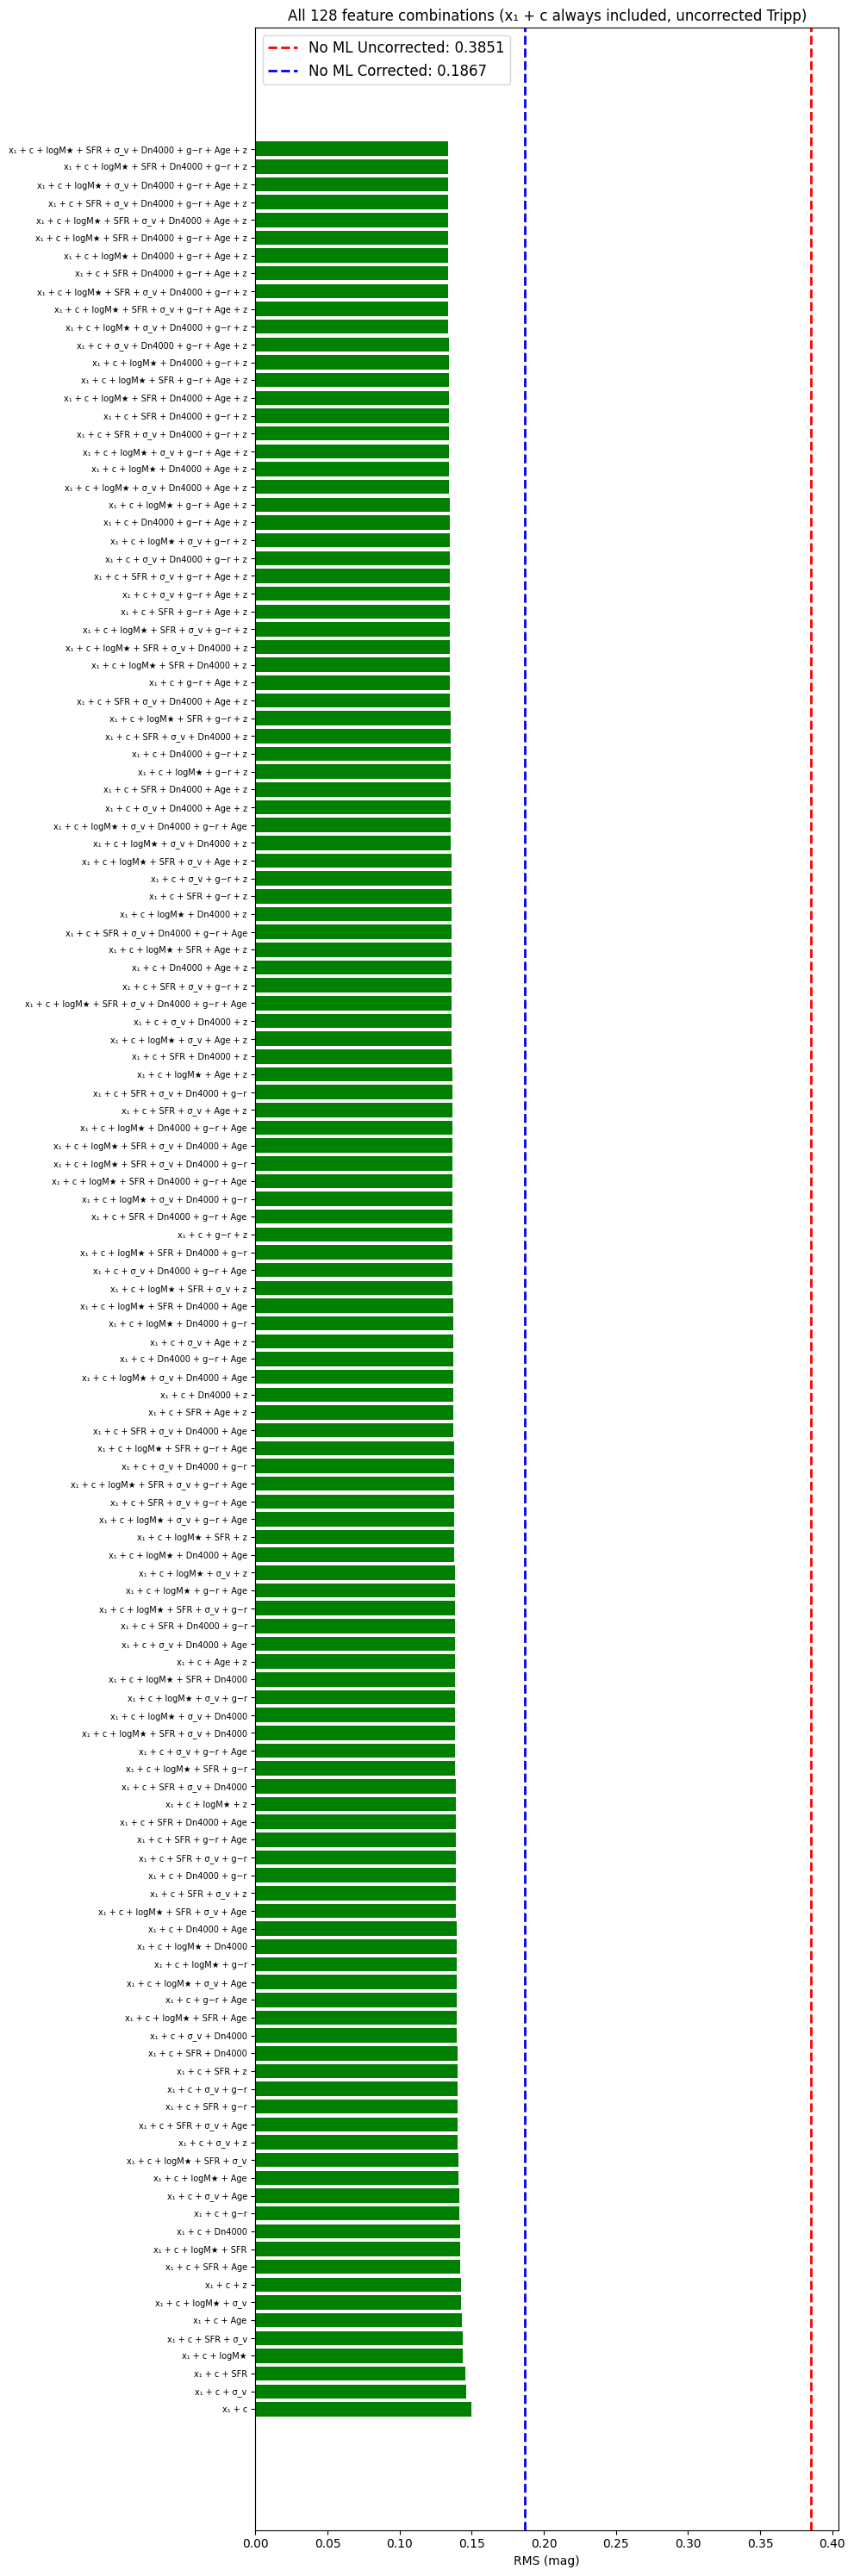

In [3]:
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

df = pd.read_csv("data/ZTF_DESI_matched_lc_cuts_z_cuts_hostprop_cleaned_tripp_uncorrected_chi2_only.csv")
y = df["residuals"]

rms_baseline = np.sqrt(np.mean(df["residuals"] ** 2))
mean_baseline = np.mean(df["residuals"])
print(f"Baseline RMS (no ML): {rms_baseline:.4f}")
print(f"Baseline mean Δμ (no ML): {mean_baseline:.4f}")

best_params = {'n_estimators': 600, 'max_depth': 26, 'min_samples_split': 7, 'min_samples_leaf': 3, 'max_features': None, 'bootstrap': True, 'max_samples': 0.5041681530892771}


fixed_features = ["ZTF_x1", "ZTF_c"]

optional_features = [
    "DESI_FASTSPEC_LOGMSTAR",
    "DESI_FASTSPEC_SFR",
    "DESI_FASTSPEC_VDISP",
    "DESI_FASTSPEC_DN4000",
    "DESI_FASTSPEC_g_minus_r",
    "DESI_FASTSPEC_AGE",
    "DESI_METADATA_Z"
]

short_names = {
    "ZTF_x1": "x₁",
    "ZTF_c": "c",
    "DESI_FASTSPEC_LOGMSTAR": "logM★",
    "DESI_FASTSPEC_SFR": "SFR",
    "DESI_FASTSPEC_VDISP": "σ_v",
    "DESI_FASTSPEC_DN4000": "Dn4000",
    "DESI_FASTSPEC_g_minus_r": "g−r",
    "DESI_FASTSPEC_AGE": "Age",
    "DESI_METADATA_Z": "z"
}

results = []

for n_opt in range(0, len(optional_features) + 1):
    for combo in combinations(optional_features, n_opt):
        combo_list = fixed_features + list(combo)

        params = best_params.copy()
        if params["max_features"] is None and len(combo_list) < 3:
            params["max_features"] = len(combo_list)

        X_combo = df[combo_list]
        rf = RandomForestRegressor(**params)
        rf.fit(X_combo, y)
        y_pred_combo = rf.predict(X_combo)

        corrected_residuals = df["residuals"] - y_pred_combo
        rms = np.sqrt(np.mean(corrected_residuals ** 2))
        mean_dmu = np.mean(corrected_residuals)

        label = " + ".join([short_names[f] for f in combo_list])
        results.append({
            "features": label,
            "n_features": len(combo_list),
            "rms": rms,
            "mean_delta_mu": mean_dmu
        })

results_df = pd.DataFrame(results).sort_values("rms", ascending=True).reset_index(drop=True)

print(results_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 30))

colors = ["green" if r < rms_baseline else "gray" for r in results_df["rms"]]
ax.barh(range(len(results_df)), results_df["rms"], color=colors)
ax.set_yticks(range(len(results_df)))
ax.set_yticklabels(results_df["features"], fontsize=7)
ax.axvline(rms_baseline, color="red", linestyle="--", linewidth=2, label=f"No ML Uncorrected: {rms_baseline:.4f}")
ax.axvline(0.1867, color="blue", linestyle="--", linewidth=2, label=f"No ML Corrected: 0.1867")
ax.set_xlabel("RMS (mag)")
ax.set_title("All 128 feature combinations (x₁ + c always included, uncorrected Tripp)")
ax.legend(fontsize=12)
ax.invert_yaxis()

plt.tight_layout()
plt.show()